In [98]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [99]:
# Задание №1
# написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока)

In [100]:
reg = pd.read_csv('../shared/problem1-reg_data.csv', sep=";")

In [36]:
reg.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [37]:
auth = pd.read_csv('../shared/problem1-auth_data.csv', sep=";")

In [38]:
auth.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [39]:
# Перевожу timestamp в datetime
reg.reg_ts = pd.to_datetime(reg.reg_ts, unit='s')
auth.auth_ts = pd.to_datetime(auth.auth_ts, unit='s')

In [40]:
# Объединяю таблицы по uid 
df = reg.merge(auth, on='uid')
df.head()

,reg_ts,uid,auth_ts
0,1998-11-18 09:43:43,1,1998-11-18 09:43:43
1,1999-07-22 22:38:09,2,1999-07-22 22:38:09
2,1999-07-22 22:38:09,2,1999-07-25 16:46:46
3,1999-07-22 22:38:09,2,1999-07-31 03:50:15
4,1999-07-22 22:38:09,2,1999-08-05 17:49:39


In [78]:
# Считаю когортный анализ за последний месяц
def cohort_retention(df, days_limit=30):

    data = df[['uid', 'reg_ts', 'auth_ts']].copy()

    # Округляю дату/время до дня 
    data['reg_date'] = data['reg_ts'].dt.floor('D')
    data['auth_date'] = data['auth_ts'].dt.floor('D')

    # Добавляю фильтр "последний месяц" относительно максимальной даты регистрации
    max_reg = data['reg_date'].max()
    # Задаю ограничение в 30 дней
    month_start = max_reg - pd.Timedelta(days=30)
    data = data[data['reg_date'] >= month_start]

    # Считаю количество дней с момента регистрации
    data['days'] = (data['auth_date'] - data['reg_date']).dt.days

    # Оставляю только корректные дни
    data = data[(data['days'] >= 0) & (data['days'] <= days_limit)]

    # Расчитываю размер когорт 
    cohort_sizes = (
        data[['uid', 'reg_date']]
        .drop_duplicates()
        .groupby('reg_date')['uid']
        .nunique()
    )

    # Считаю уникальных пользователей по когортам и дням
    retention = (
        data.groupby(['reg_date', 'days'])['uid']
        .nunique()
        .unstack('days')
    )

    # Делю на размер когорты
    retention = retention.div(cohort_sizes, axis=0)
    
    # Создаю сводную таблицу для когортного анализа
    cohort_table = (
        retention
        .sort_index()
        .style        
        .background_gradient(
    cmap='Blues',
    subset=retention.columns[1:],
    vmin=0,
    vmax=retention.iloc[:, 1:].max().max()
)
        .highlight_null('white')
        .format("{:.2%}", na_rep="")
    )

    return cohort_table

In [79]:
cohort_retention(df, days_limit=14)

days,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
reg_date,,,,,,,,,,,,,,,
2020-08-24 00:00:00,100.00%,1.79%,4.15%,4.28%,5.11%,5.75%,7.60%,6.01%,4.92%,5.18%,5.18%,4.79%,6.01%,5.56%,4.54%
2020-08-25 00:00:00,100.00%,1.98%,4.40%,4.79%,5.68%,5.30%,5.30%,6.25%,3.70%,5.74%,4.72%,5.04%,4.21%,4.79%,4.34%
2020-08-26 00:00:00,100.00%,1.46%,3.44%,4.20%,4.52%,6.43%,6.56%,5.99%,4.59%,4.33%,4.08%,5.92%,4.78%,4.39%,4.78%
2020-08-27 00:00:00,100.00%,1.65%,3.37%,4.77%,5.21%,5.53%,6.17%,5.72%,4.32%,5.40%,5.40%,5.28%,4.45%,5.15%,4.20%
2020-08-28 00:00:00,100.00%,2.03%,4.57%,5.27%,4.76%,6.29%,6.22%,5.46%,5.59%,5.27%,4.83%,4.63%,5.40%,4.38%,4.89%
2020-08-29 00:00:00,100.00%,2.53%,3.74%,4.63%,5.70%,5.51%,6.97%,5.70%,4.56%,6.02%,4.31%,4.56%,6.65%,4.75%,5.39%
2020-08-30 00:00:00,100.00%,1.84%,3.48%,3.92%,5.38%,5.95%,6.58%,5.57%,4.30%,4.30%,5.19%,4.81%,5.13%,4.56%,4.11%
2020-08-31 00:00:00,100.00%,1.83%,3.66%,4.23%,5.12%,6.89%,6.51%,6.70%,4.80%,5.37%,5.05%,5.31%,4.86%,4.42%,3.85%
2020-09-01 00:00:00,100.00%,2.02%,4.10%,4.22%,4.60%,6.43%,5.61%,6.43%,4.10%,5.42%,5.11%,5.36%,4.85%,5.49%,4.29%


In [224]:
# Задание № 2

In [81]:
problem2 = pd.read_csv('Проект_1_Задание_2.csv', sep=";")

In [82]:
problem2

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [83]:
# Создаю флаг платящего клиента
problem2['is_payer'] = (problem2['revenue'] > 0).astype(int)
problem2.head()

,user_id,revenue,testgroup,is_payer
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0


In [84]:
# Сначала расчитываю основные показатели по группам
group_stats = (
    problem2
    .groupby('testgroup')
    .agg(
        users=('user_id', 'nunique'),
        paying_users=('is_payer', 'sum'),
        total_revenue=('revenue', 'sum')
    )
)

group_stats['CR'] = group_stats['paying_users'] / group_stats['users'] * 100
group_stats['ARPU'] = group_stats['total_revenue'] / group_stats['users']
group_stats['ARPPU'] = group_stats['total_revenue'] / group_stats['paying_users']

group_stats

,users,paying_users,total_revenue,CR,ARPU,ARPPU
testgroup,,,,,,
a,202103,1928,5136189,0.953969,25.413720,2663.998444
b,202667,1805,5421603,0.890624,26.751287,3003.658172


In [85]:
# Проверяю условие из задачи
group_stats.loc['b', 'ARPU'] / group_stats.loc['a', 'ARPU'] - 1

0.05263168360069903

In [86]:
# Хочу посмотреть на максимальный и минимальный платеж у платящих клиентов
problem2[problem2['revenue'] > 0].sort_values(by='revenue', ascending=False)

,user_id,revenue,testgroup,is_payer
101861,101862,37433,a,1
196601,196602,37407,a,1
65077,65078,37394,a,1
21585,21586,37385,a,1
142804,142805,37379,a,1
...,...,...,...,...
104975,104976,200,a,1
119128,119129,200,a,1
393140,393141,200,a,1
66262,66263,200,a,1


In [87]:
# Так как ARPU вырос, а CR упал у тестовой группы, нужно посмотреть распределение платежей
payer_dist = (
    problem2[problem2['revenue'] > 0]
    .groupby('testgroup')['revenue']
    .quantile([0.25, 0.5, 0.75, 0.9, 0.95]) # т.к. имеются сильные выбросы добавляю еще 95 процентиль, чтобы увидеть выброс
    .unstack()
)

payer_dist

,0.25,0.50,0.75,0.90,0.95
testgroup,,,,,
a,257.0,311.0,361.0,393.3,37299.65
b,2513.0,3022.0,3478.0,3795.8,3891.80


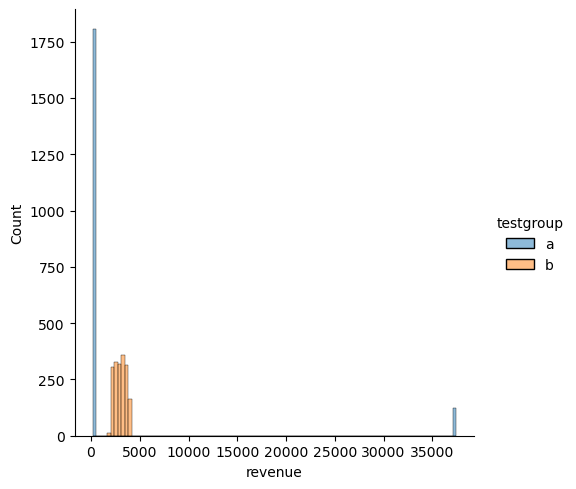

In [88]:
# + на графике посмотреть
paid_df = problem2[problem2['revenue'] > 0]
sns.displot(data=paid_df,x='revenue',hue='testgroup')

In [89]:
# Теперь видно, что в тестовой группе средний чек вырос по всем квантилям распределения, включая медиану, что говорит о массовом увеличении трат среди платящих пользователей. 
# В контрольной группе рост средних метрик искажается наличием экстремальных выбросов в верхнем хвосте. 
# Таким образом, рост ARPU в тесте обеспечен изменением поведения большинства платящих, а не отдельными «китами».

In [90]:
# Еще можно посмотреть какая доля всей выручки приходится на топ 10% платящих клиентов 
def top_share(data, q=0.1):
    threshold = data['revenue'].quantile(1 - q)
    return data[data['revenue'] >= threshold]['revenue'].sum() / data['revenue'].sum()

top_revenue_share = (
    problem2[problem2['revenue'] > 0]
    .groupby('testgroup')
    .apply(top_share)
)

top_revenue_share

testgroup
a    0.899119
b    0.130083
dtype: float64

In [91]:
# В контрольной группе почти 90% всей выручки приходится на этих топ-10% платящих пользователей, получается, что почти весь доход зависит от небольшого числа «китов». 
# В тестовой группе вклад топ-10% составляет лишь около 13%, что говорит о значительно более равномерном распределении выручки между платящими пользователями. 
# Таким образом, рост ARPU в тесте является более устойчивым и менее подверженным риску отдельных выбросов.

In [92]:
# Теперь необходимо оценить стат значимость различий ARPU, буду использовать бутстрап, так как распределение выручки 
# по пользователям является сильно асимметричным и содержит выбросы.
def bootstrap_arpu(data, n_iter=10000):
    arpu = []
    for _ in range(n_iter):
        sample = data.sample(frac=1, replace=True)
        arpu.append(sample['revenue'].mean())
    return np.array(arpu)

arpu_a = bootstrap_arpu(problem2[problem2['testgroup'] == 'a'])
arpu_b = bootstrap_arpu(problem2[problem2['testgroup'] == 'b'])

diff = arpu_b - arpu_a

np.percentile(diff, [2.5, 50, 97.5])

array([-2.9835126 ,  1.33816621,  5.43417676])

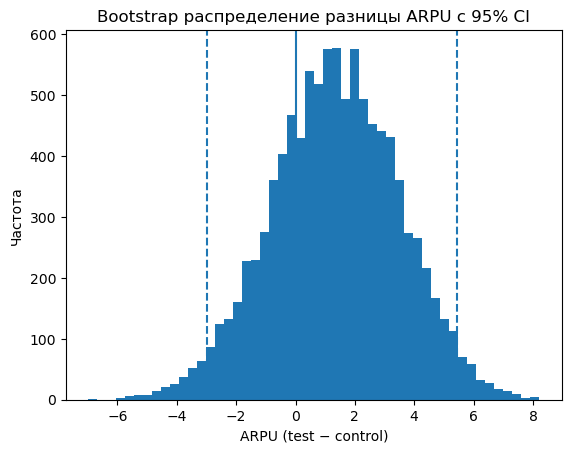

In [93]:
# Строю график
ci_low, ci_med, ci_high = np.percentile(diff, [2.5, 50, 97.5])

plt.figure()
plt.hist(diff, bins=50)
plt.axvline(0)
plt.axvline(ci_low, linestyle='--')
plt.axvline(ci_high, linestyle='--')
plt.xlabel('ARPU (test − control)')
plt.ylabel('Частота')
plt.title('Bootstrap распределение разницы ARPU с 95% CI')
plt.show()

In [94]:
# Статистически значимого различия в ARPU между тестовой и контрольной группами не выявлено.
# Доверительный интервал включает 0. Хотя медиана разницы положительна (1.3%), нельзя утверждать, 
# что тестовая группа действительно увеличивает средний доход на пользователя.

In [101]:
# Аналогично проверяю стат значимость ARPPU

def bootstrap_arppu(data, n_iter=10000):
    arppu = []
    
    # оставляем только платящих
    payers = data[data['revenue'] > 0]
    
    for _ in range(n_iter):
        sample = payers.sample(frac=1, replace=True)
        arppu.append(sample['revenue'].mean())
        
    return np.array(arppu)


arppu_a = bootstrap_arppu(problem2[problem2['testgroup'] == 'a'])
arppu_b = bootstrap_arppu(problem2[problem2['testgroup'] == 'b'])

diff_arppu = arppu_b - arppu_a

np.percentile(diff_arppu, [2.5, 50, 97.5])

array([-77.09219146, 342.72412616, 736.95760162])

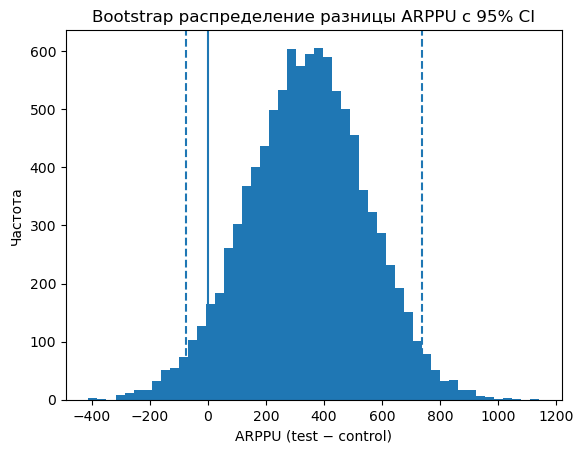

In [102]:
# Строю график
ci_low, ci_med, ci_high = np.percentile(diff_arppu, [2.5, 50, 97.5])

plt.figure()
plt.hist(diff_arppu, bins=50)
plt.axvline(0)
plt.axvline(ci_low, linestyle='--')
plt.axvline(ci_high, linestyle='--')
plt.xlabel('ARPPU (test − control)')
plt.ylabel('Частота')
plt.title('Bootstrap распределение разницы ARPPU с 95% CI')
plt.show()

In [ ]:
# Проверка показала, что статистически значимого различия в ARPPU между тестовой и контрольной группами не выявлено.
# Доверительный интервал включает 0. 

In [244]:
# Теперь нужно проверить изменения в CR, действительно ли набор акционных предложений влияет на CR? 
# Выдвигаю H₀ - что конверсия в платёж одинакова в тесте и контроле (вся разница — случайность)
# H₁- что конверсия в платёж различается между группами (набор предложений реально влияет)
# Применяю z-test для пропорций, так как метрика является бинарной, а размеры выборок достаточно велики для нормальной аппроксимации распределения выборочной доли.

control = group_stats.loc['a']
test = group_stats.loc['b']

counts = np.array([test['paying_users'], control['paying_users']])
nobs = np.array([test['users'], control['users']])

z_stat, p_value = proportions_ztest(counts, nobs)

z_stat, p_value

(-2.108028495889841, 0.035028524642854865)

In [103]:
# Проверка показала, что имеется стат значимое различие между группами. 
# Таким образом, тестовый набор предложений статистически значимо снижает конверсию в платёж по сравнению с контрольной группой. 

In [104]:
# На основании результатов A/B-теста ни один из наборов предложений нельзя однозначно признать лучшим.

# Тестовый набор предложений:
# показывает номинальный рост ARPU и ARPPU, но этот рост не является статистически значимым;
# при этом статистически значимо снижает конверсию в платёж, что ухудшает верхнюю часть воронки монетизации.

# Контрольный набор предложений:
# обеспечивает более высокую конверсию в платёж,
# однако выручка сильно сконцентрирована на небольшом числе топ-платящих пользователей, что делает доход менее устойчивым.
# Для принятия окончательного решения требуется доработкa наборов предложений и повторное тестирование.

In [105]:
# Задание № 3

In [106]:
# С помощью каких метрик можно оценить результаты последнего прошедшего события?

# Для подбора метрик сначала необходимо определить цели проведения тематических событий:
# 1. Рост монетизации
# 2. Повышение вовлеченности 
# 3. Удержание игроков 
# 4. Стимулирование прогресса игроков

# Метрики роста:
# 1. ARPU / ARPPU участников события, показывает монетизационную активность события
# 2. Дневной retention, как событие влияет на долгосрочное удержание
# 3. Доля игроков совершавших покупки в событии, показывает монетизационную активность события
# 4. Доля игроков учавствующих в событии (кол-во игроков начавших событие / общее число активных игроков(в период прохождения события) * 100), охват события 
# 5. Количество уникальных участников события, для сравнения с предыдущими событиями

# Продуктовые метрики:
# 1. Доля игроков завершивших событие полностью, оценка прогресса и сложности
# 2. Доля игроков получивших хотя бы одну награду, оценка прогресса и сложности
# 3. Среднее число попыток прохождения уровня, оценка прогресса и сложности
# 4. Среднее количество сессий на игрока во время события, оценка вовлеченности
# 5. Средняя длительность сессии, оценка вовлеченности
# 6. Доля игроков использовавших награду(хотя бы одну), оценка пользы события

# Изменится ли набор метрик оценки результата? Если да, то как?

# Набор метрик дополнится, т.к. добавляется риск фрустрации
# 1. Доля неудачных попыток, оценка баланса и риска выгорания
# 2. Среднее количество уровней отката, измеряет насколько сурово наказание за ошибку влияет на прогресс
# 3. Доля игроков, бросивших событие после первой неудачи, позволяет оценить негативное влияние механики на удержание
# 4. Отток игроков на уровне N, можно использовать heatmap, на каких уровнях игроки чаще всего бросают событие
# 5. Доля игроков, покупавших бустеры после отката, насколько игроки готовы тратить деньги, чтобы компенсировать сложность
# 6. Средняя длительность сессии после неудачной попытки, как влияет откат на поведение игрока
